# Lab Assignment 3 - Latent Space Classification
# Notebook 1: Train Convolutional Autoencoder

**Authors:**
- Patricia Guadalupe Alvarenga Mairena
- Francisco Manuel Vázquez Fernández

## 1. Import Libraries and Setup

In [3]:
# Run this cell only on Google Colab
import sys
if 'google.colab' in sys.modules:
    !pip install -q tensorflow-datasets

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
    # Reduces the number of warnings
    
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

# Configure matplotlib for inline plotting
%matplotlib inline

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*60)
print("STL-10 Dataset CNN Classifier")
print("="*60)
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("="*60)

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
# To avoid stalling due to memory problems

STL-10 Dataset CNN Classifier
TensorFlow version: 2.20.0
Keras version: 3.13.2
GPU Available: True


## 2. Configuration parameters

In [6]:
IMG_SIZE = 96  # STL-10 native size
BATCH_SIZE = 128
EPOCHS = 200
NUM_CLASSES = 10  # airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck
INITIAL_LR = 0.001
LATENT_DIM = 256  # Size of the bottleneck representation

# Class names for visualization
CLASS_NAMES = ['airplane', 'bird', 'car', 'cat', 'deer', 
               'dog', 'horse', 'monkey', 'ship', 'truck']

# Output dir — save to Drive on Colab so models persist
import sys
if 'google.colab' in sys.modules:
    SAVE_DIR = "/content/drive/MyDrive/DL_Practice_3"
    import os; os.makedirs(SAVE_DIR, exist_ok=True)
else:
    SAVE_DIR = "."

print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Initial Learning Rate: {INITIAL_LR}")
print(f"Latent Dimension: {LATENT_DIM}")
print(f"Save dir: {SAVE_DIR}")
print(f"\nClasses: {', '.join(CLASS_NAMES)}")
print(f"\nCompression ratio: {IMG_SIZE*IMG_SIZE*3} -> {LATENT_DIM} ({IMG_SIZE*IMG_SIZE*3/LATENT_DIM:.1f}x)")

Image Size: 96x96
Batch Size: 128
Epochs: 200
Number of Classes: 10
Initial Learning Rate: 0.001
Latent Dimension: 256
Save dir: /content/drive/MyDrive/DL_Practice_3

Classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck

Compression ratio: 27648 -> 256 (108.0x)


## 3. Load STL-10 dataset

In [13]:
print("  Downloading STL-10 dataset...\n")

# Cache dataset on Google Drive so we don't re-download every session
import sys
DATA_DIR = "/content/drive/MyDrive/DL_datasets" if 'google.colab' in sys.modules else None

ds_unlabeled, ds_info = tfds.load(
    "stl10",
    split="unlabelled",
    as_supervised=False,
    with_info=True,
    data_dir=DATA_DIR
)


def ae_preprocess(example):
    image = tf.cast(example["image"], tf.float32) / 255.0
    return image, image


# NOTE: .cache() removed to avoid OOM on Colab (100k images at float32 ≈ 10.6 GB RAM)
ds_unlabeled = (
    ds_unlabeled
    .map(ae_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .shuffle(5000)
    .batch(BATCH_SIZE)
    .repeat()
    .prefetch(tf.data.AUTOTUNE)
)

unlabelled_size = ds_info.splits['unlabelled'].num_examples

print(f"  Dataset loaded successfully!")
print(f"   Number of samples: {unlabelled_size}")
print(f"   Image shape: {ds_info.features['image'].shape}")
print(f"   Data dir: {DATA_DIR or 'default (~/.tensorflow_datasets)'}")


  Dataset loaded successfully!
   Number of samples: 100000
   Image shape: (96, 96, 3)
   Data dir: /content/drive/MyDrive/DL_datasets


**Important:** When loading the models, using ``.repeat()`` helps prevent errors caused by corrupted samples. You must then specify the ``steps_per_epoch`` argument during training as shown below.

````
steps_per_epoch = unlabelled_size // BATCH_SIZE
autoencoder.fit(
    ds_unlabeled,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=None
)


## 4. Build the Convolutional Autoencoder

We use a symmetric convolutional autoencoder. The **encoder** compresses a 96×96×3 image (27,648 values) down to a 256-dimensional latent vector — roughly a 108:1 compression ratio.

**Architecture choices:**
- **Strided convolutions** instead of MaxPooling for downsampling — this way the network learns its own downsampling filters rather than using a fixed operation.
- **Batch normalization** after each conv layer to stabilize training and allow higher learning rates.
- **ReLU activations** throughout (standard choice for deep nets).
- **Dense bottleneck** (Flatten → Dense(256)) to get a compact 1D latent vector, which makes it easy to plug into a classifier later.
- **Sigmoid output** on the decoder since our images are normalized to [0, 1].
- The decoder mirrors the encoder using `Conv2DTranspose` (transposed convolutions) to upsample back to 96×96×3.

In [14]:
def build_encoder(input_shape=(IMG_SIZE, IMG_SIZE, 3), latent_dim=LATENT_DIM):
    """Encoder: 96x96x3 -> latent_dim vector"""
    inputs = layers.Input(shape=input_shape, name="encoder_input")
    
    # Block 1: 96x96x3 -> 48x48x32
    x = layers.Conv2D(32, 3, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Block 2: 48x48x32 -> 24x24x64
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Block 3: 24x24x64 -> 12x12x128
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Block 4: 12x12x128 -> 6x6x256
    x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Flatten and compress to latent vector
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, name="latent_vector")(x)
    
    encoder = models.Model(inputs, latent, name="encoder")
    return encoder

encoder = build_encoder()
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 256)            │     2,359,552 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,749,888 (10.49 MB)

 Trainable params: 2,748,928 (10.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [15]:
def build_decoder(latent_dim=LATENT_DIM):
    """Decoder: latent_dim vector -> 96x96x3 image"""
    latent_input = layers.Input(shape=(latent_dim,), name="decoder_input")
    
    # Project and reshape to spatial format: 6x6x256
    x = layers.Dense(6 * 6 * 256)(latent_input)
    x = layers.ReLU()(x)
    x = layers.Reshape((6, 6, 256))(x)
    
    # Block 1: 6x6x256 -> 12x12x128
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Block 2: 12x12x128 -> 24x24x64
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Block 3: 24x24x64 -> 48x48x32
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Block 4: 48x48x32 -> 96x96x3 (sigmoid for [0,1] output)
    outputs = layers.Conv2DTranspose(3, 3, strides=2, padding="same", activation="sigmoid")(x)
    
    decoder = models.Model(latent_input, outputs, name="decoder")
    return decoder

decoder = build_decoder()
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9216)           │     2,368,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 12, 12, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 24, 24, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 48, 48, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_15 (ReLU)                 │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 96, 96, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,757,571 (10.52 MB)

 Trainable params: 2,757,123 (10.52 MB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
# Build the full autoencoder: encoder -> decoder
ae_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="ae_input")
latent = encoder(ae_input)
ae_output = decoder(latent)

autoencoder = models.Model(ae_input, ae_output, name="autoencoder")

print(f"Encoder:     {encoder.count_params():,} parameters")
print(f"Decoder:     {decoder.count_params():,} parameters")
print(f"Autoencoder: {autoencoder.count_params():,} parameters")
print(f"\nInput shape:  {autoencoder.input_shape}")
print(f"Output shape: {autoencoder.output_shape}")
print(f"Latent dim:   {LATENT_DIM}")

Encoder:     2,749,888 parameters
Decoder:     2,757,571 parameters
Autoencoder: 5,507,459 parameters

Input shape:  (None, 96, 96, 3)
Output shape: (None, 96, 96, 3)
Latent dim:   256


## 5. Train the Autoencoder

We compile the autoencoder with **MSE loss** — this is the standard choice for reconstruction since we want the output pixel values to match the input. Adam optimizer with a learning rate of 0.001.

**Callbacks:**
- **ReduceLROnPlateau**: if the loss stalls for 5 epochs, reduce the LR by 0.5. This helps escape plateaus without having to manually tune a schedule.
- **EarlyStopping**: stop training if the loss hasn't improved in 15 epochs. Prevents wasting time once the model has converged.

We use `steps_per_epoch` because of the `.repeat()` in the data pipeline (needed to handle corrupted samples gracefully).

In [ ]:
import os

# Checkpoint path (on Drive so it survives disconnections)
CKPT_PATH = os.path.join(SAVE_DIR, "ae_checkpoint.keras")

# Try to resume from checkpoint
initial_epoch = 0
if os.path.exists(CKPT_PATH):
    print(f"Found checkpoint at {CKPT_PATH}, loading weights...")
    autoencoder.load_weights(CKPT_PATH)
    # Try to figure out which epoch we were at from saved history
    if os.path.exists(os.path.join(SAVE_DIR, "ae_history.npy")):
        prev = np.load(os.path.join(SAVE_DIR, "ae_history.npy"), allow_pickle=True).item()
        initial_epoch = len(prev.get("loss", []))
        print(f"Resuming from epoch {initial_epoch}")
    else:
        print("No history found, starting epoch count from 0 with loaded weights")
else:
    print("No checkpoint found, training from scratch")

# Compile
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss="mse"
)

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        CKPT_PATH,
        monitor="loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

# Train
steps_per_epoch = unlabelled_size // BATCH_SIZE

print(f"\nSteps per epoch: {steps_per_epoch}")
print(f"Total samples: {unlabelled_size}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Starting from epoch: {initial_epoch}")
print(f"Checkpoint: {CKPT_PATH}")
print(f"Starting training...\n")

history = autoencoder.fit(
    ds_unlabeled,
    epochs=EPOCHS,
    initial_epoch=initial_epoch,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks
)

# Save history so we can resume later
if os.path.exists(os.path.join(SAVE_DIR, "ae_history.npy")):
    prev = np.load(os.path.join(SAVE_DIR, "ae_history.npy"), allow_pickle=True).item()
    for k in history.history:
        prev[k] = prev.get(k, []) + history.history[k]
    np.save(os.path.join(SAVE_DIR, "ae_history.npy"), prev)
    history.history = prev
else:
    np.save(os.path.join(SAVE_DIR, "ae_history.npy"), history.history)

Steps per epoch: 781
Total samples: 100000
Batch size: 128
Starting training...

Epoch 1/200
781/781 ━━━━━━━━━━━━━━━━━━━━ 72s 73ms/step - loss: 0.0202 - learning_rate: 0.0010
Epoch 2/200
781/781 ━━━━━━━━━━━━━━━━━━━━ 62s 71ms/step - loss: 0.0119 - learning_rate: 0.0010
Epoch 3/200
781/781 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - loss: 0.0103 - learning_rate: 0.0010
Epoch 4/200
781/781 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - loss: 0.0096 - learning_rate: 0.0010
Epoch 5/200
781/781 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - loss: 0.0093 - learning_rate: 0.0010
Epoch 6/200
781/781 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/step - loss: 0.0091 - learning_rate: 0.0010
Epoch 7/200
781/781 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - loss: 0.0090 - learning_rate: 0.0010
Epoch 8/200
781/781 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - loss: 0.0089 - learning_rate: 0.0010
Epoch 9/200
781/781 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - loss: 0.0088 - learning_rate: 0.0010
Epoch 10/200
781/781 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - loss: 0.0088 - 

: 

## 6. Training Curves

In [17]:
# Load history from Drive (survives interruptions)
hist_path = os.path.join(SAVE_DIR, "ae_history.npy")
if 'history' not in dir() or not hasattr(history, 'history'):
    if os.path.exists(hist_path):
        hist_data = np.load(hist_path, allow_pickle=True).item()
        print(f"Loaded history from {hist_path} ({len(hist_data['loss'])} epochs)")
    else:
        raise FileNotFoundError(f"No history found at {hist_path}. Run training first.")
else:
    hist_data = history.history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(hist_data["loss"], label="Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Autoencoder Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Learning rate curve
lr_key = "lr" if "lr" in hist_data else "learning_rate"
if lr_key in hist_data:
    axes[1].plot(hist_data[lr_key], label="Learning Rate", color="orange")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Learning Rate")
    axes[1].set_title("Learning Rate Schedule")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_yscale("log")

plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()

print(f"\nFinal loss: {hist_data['loss'][-1]:.6f}")
print(f"Best loss:  {min(hist_data['loss']):.6f}")
print(f"Epochs trained: {len(hist_data['loss'])}")
print(f"Figure saved to {SAVE_DIR}/training_curves.png")

FileNotFoundError: No history found at /content/drive/MyDrive/DL_Practice_3/ae_history.npy. Run training first.

## 7. Visualize Reconstructions

Let's look at a few input images and their reconstructions to see how well the autoencoder learned. We don't expect pixel-perfect results with a 108:1 compression ratio, but the reconstructions should capture the overall structure and color of each image.

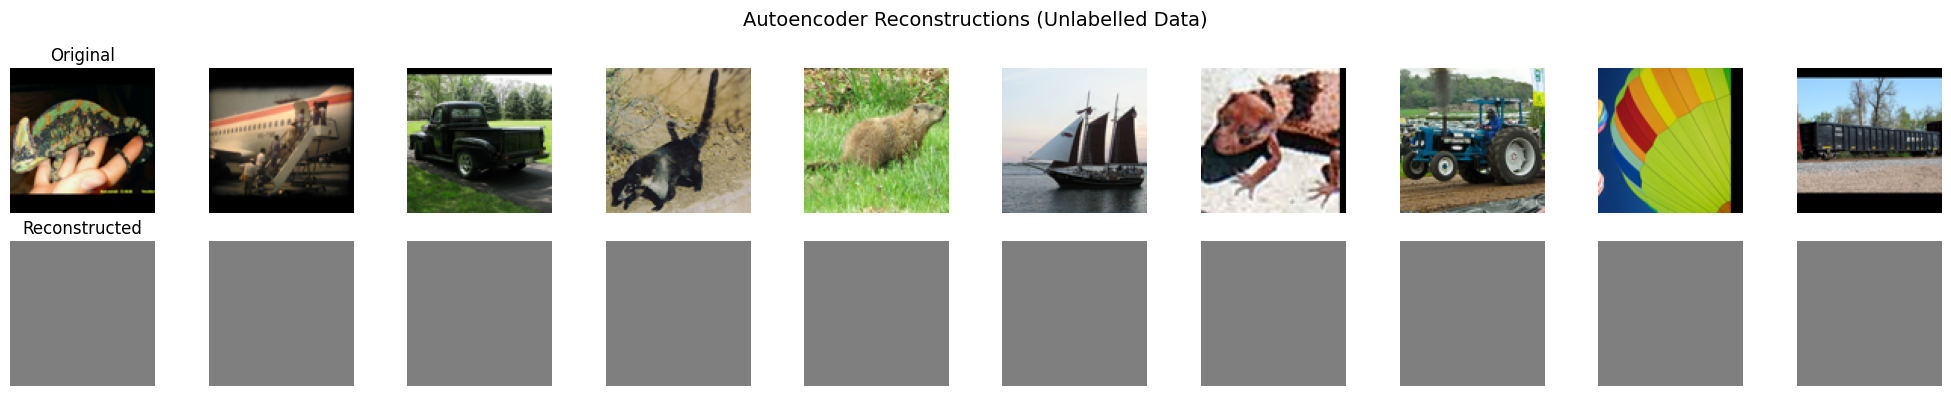

Per-image MSE: 0.096652 ± 0.036037
Figure saved to /content/drive/MyDrive/DL_Practice_3/reconstructions.png


In [18]:
# Load checkpoint if weights were lost (e.g., after reconnection)
ckpt_path = os.path.join(SAVE_DIR, "ae_checkpoint.keras")
if os.path.exists(ckpt_path):
    autoencoder.load_weights(ckpt_path)
    print(f"Loaded best weights from {ckpt_path}")

# Grab a batch of images for visualization
sample_batch = next(iter(ds_unlabeled))
sample_images = sample_batch[0][:10]  # Take 10 images

# Get reconstructions
reconstructed = autoencoder.predict(sample_images, verbose=0)

# Plot original vs reconstructed
n = 10
fig, axes = plt.subplots(2, n, figsize=(20, 4))

for i in range(n):
    # Original
    axes[0, i].imshow(sample_images[i].numpy())
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", fontsize=12)
    
    # Reconstructed
    axes[1, i].imshow(np.clip(reconstructed[i], 0, 1))
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Reconstructed", fontsize=12)

plt.suptitle("Autoencoder Reconstructions (Unlabelled Data)", fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "reconstructions.png"), dpi=150)
plt.show()

# Per-image MSE
per_image_mse = np.mean((sample_images.numpy() - reconstructed) ** 2, axis=(1, 2, 3))
print(f"Per-image MSE: {per_image_mse.mean():.6f} ± {per_image_mse.std():.6f}")
print(f"Figure saved to {SAVE_DIR}/reconstructions.png")

## 8. Save the Encoder

We save the trained encoder so we can load it in the next notebook for latent space classification. We also save the full autoencoder in case we want to revisit it later.

In [19]:
import os
# Save models to SAVE_DIR (Drive on Colab, local otherwise)
encoder.save(os.path.join(SAVE_DIR, "encoder.keras"))
autoencoder.save(os.path.join(SAVE_DIR, "autoencoder.keras"))

print("Models saved:")
print(f"  - {SAVE_DIR}/encoder.keras")
print(f"  - {SAVE_DIR}/autoencoder.keras")
print(f"\nEncoder output shape: {encoder.output_shape}")
print("Ready to use for latent space classification in notebook 2.")

Models saved:
  - /content/drive/MyDrive/DL_Practice_3/encoder.keras
  - /content/drive/MyDrive/DL_Practice_3/autoencoder.keras

Encoder output shape: (None, 256)
Ready to use for latent space classification in notebook 2.


## AI Tool Usage Declaration

We used **GitHub Copilot** (Claude-based, integrated in VS Code) as a support tool during this lab. How it was used:

- **Architecture exploration**: we asked Copilot to suggest typical convolutional autoencoder designs for 96×96 images and to compare alternatives (strided convolutions vs. MaxPooling, where to place BatchNorm, sigmoid vs. tanh output activation, choice of latent dimension). We then discussed the trade-offs and picked the design we could justify ourselves.
- **Boilerplate / Keras syntax**: speeding up writing of `tf.data` pipeline code, `model.fit` callbacks (`ReduceLROnPlateau`, `EarlyStopping`), and plotting code for training curves and reconstructions.
- **Debugging**: helping interpret error messages (e.g., shape mismatches between encoder output and decoder input, issues with `.repeat()` and `steps_per_epoch`).
- **Markdown explanations**: drafting the report cells, which we then reviewed and edited so they actually reflect *our* reasoning and decisions.

Every layer, hyperparameter, and regularization choice was discussed between us before being added to the notebook, and we can justify each of them.

**Usefulness**: very useful for speeding up the boring parts (boilerplate, plotting, syntax lookups) and as a brainstorming partner for design alternatives. Less useful for the actual reasoning about *why* a given choice fits this dataset